In [ ]:
%pip install cartopy

### Upload Required CSV Files

It appears that the necessary CSV files were not found, causing the `all_generators_df` DataFrame to be empty. Please upload the following files to your Colab environment to proceed with the analysis:

*   `/content/december_generator2025_OP.csv`
*   `/content/december_generator2023_OP.csv`
*   `/content/december_generator2024_OP.csv`
*   `/content/december_generator2022_PLANNED.csv`
*   `/content/december_generator2025_PLANNED.csv`
*   `/content/december_generator2024_PLANNED.csv`
*   `/content/december_generator2022_OP.csv`
*   `/content/december_generator2023_PLANNED.csv`

You can upload these files by dragging and dropping them into the 'Files' section on the left sidebar of your Colab notebook. Once uploaded, please re-run the previous cell (cell `a2653e14`) to load the data, and then re-run the current cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os # import os for paths

# --- user config: update this path to your csvs ---
base_directory = '/content/' # default: assuming files in /content/

# all generator csv filenames
csv_filenames = [
    'december_generator2025_OP.csv',
    'december_generator2023_OP.csv',
    'december_generator2024_OP.csv',
    'december_generator2022_PLANNED.csv',
    'december_generator2025_PLANNED.csv',
    'december_generator2024_PLANNED.csv',
    'december_generator2022_OP.csv',
    'december_generator2023_PLANNED.csv'
]

# create full paths
csv_files = [os.path.join(base_directory, filename) for filename in csv_filenames]

all_generators_df = pd.DataFrame()

for file_path in csv_files:
    try:
        df_temp = pd.read_csv(file_path)
        # add a column to identify operating vs. planned files
        if '_OP.csv' in file_path:
            df_temp['File_Type'] = 'Operating'
        elif '_PLANNED.csv' in file_path:
            df_temp['File_Type'] = 'Planned'
        all_generators_df = pd.concat([all_generators_df, df_temp], ignore_index=True)
    except FileNotFoundError:
        print(f"warning: file not found at {file_path}. skipping this file.")

# drop duplicates based on entity id, plant id, and operating year
# assuming entity id + plant id + operating year is unique per generator unit
# only drop if df not empty and has required columns
if not all_generators_df.empty and all(col in all_generators_df.columns for col in ['Entity ID', 'Plant ID', 'Operating Year']):
    all_generators_df.drop_duplicates(subset=['Entity ID', 'Plant ID', 'Operating Year'], inplace=True)


print("combined dataframe info:")
display(all_generators_df.info())
display(all_generators_df.head())

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 39467 entries, 0 to 112170
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity ID                 39466 non-null  object 
 1   Plant ID                  39463 non-null  float64
 2   Sector                    39463 non-null  object 
 3   Nameplate Capacity (MW)   39463 non-null  object 
 4   Net Summer Capacity (MW)  39463 non-null  object 
 5   Net Winter Capacity (MW)  39463 non-null  object 
 6   Technology                39463 non-null  object 
 7   Operating Month           36452 non-null  float64
 8   Operating Year            36452 non-null  float64
 9   Planned Retirement Month  36452 non-null  object 
 10  Planned Retirement Year   36452 non-null  object 
 11  Status                    39463 non-null  object 
 12  Latitude                  39463 non-null  object 
 13  Longitude                 39463 non-null

None

,Entity ID,Plant ID,Sector,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Operating Month,Operating Year,Planned Retirement Month,Planned Retirement Year,Status,Latitude,Longitude,File_Type,Planned Operation Month,Planned Operation Year
0,63560,1.0,Electric Utility,0.9,0.4,0.4,Petroleum Liquids,12.0,2000.0,,,SB,55.339722,-160.4972,Operating,NaN,NaN
2,63560,1.0,Electric Utility,0.5,0.3,0.3,Petroleum Liquids,12.0,2010.0,,,OP,55.339722,-160.4972,Operating,NaN,NaN
3,63560,1.0,Electric Utility,0.4,0.3,0.3,Petroleum Liquids,2.0,2023.0,,,OP,55.339722,-160.4972,Operating,NaN,NaN
4,63560,1.0,Electric Utility,0.5,0.1,0.1,Onshore Wind Turbine,10.0,2011.0,,,OS,55.339722,-160.4972,Operating,NaN,NaN
6,195,2.0,Electric Utility,53.9,53,53,Conventional Hydroelectric,7.0,1963.0,,,OP,33.458665,-87.35682,Operating,NaN,NaN


Now, let's clean the 'Nameplate Capacity (MW)' column and categorize the generators based on their status (Operating, Planned 2026, 2027, 2028+).

In [ ]:
# convert 'nameplate capacity (mw)' to numeric (handle errors)
all_generators_df['Nameplate Capacity (MW)'] = pd.to_numeric(
    all_generators_df['Nameplate Capacity (MW)'], errors='coerce'
)

# fill nan capacity with 0, as missing capacity means zero
all_generators_df['Nameplate Capacity (MW)'] = all_generators_df['Nameplate Capacity (MW)'].fillna(0)

# filter for solar and wind
clean_energy_technologies = [
    'Solar Photovoltaic', 'Onshore Wind Turbine', 'Offshore Wind Turbine',
    'Solar Thermal with Energy Storage', 'Solar Thermal without Energy Storage'
]

clean_energy_df = all_generators_df[
    all_generators_df['Technology'].isin(clean_energy_technologies)
].copy()

# ensure 'operating year' and 'planned operation year' are numeric
clean_energy_df['Operating Year'] = pd.to_numeric(clean_energy_df['Operating Year'], errors='coerce')
clean_energy_df['Planned Operation Year'] = pd.to_numeric(clean_energy_df['Planned Operation Year'], errors='coerce')


# categorize status for x-axis, including historical operating years
def categorize_status_v2(row):
    if row['File_Type'] == 'Operating':
        op_year = row['Operating Year']
        if pd.isna(op_year):
            return 'other'
        # group operating years into distinct categories for recent years
        if op_year == 2022:
            return 'operating 2022'
        elif op_year == 2023:
            return 'operating 2023'
        elif op_year == 2024:
            return 'operating 2024'
        elif op_year == 2025:
            return 'operating 2025'
        else:
            return 'other operating years' # for any other operating years

    elif row['File_Type'] == 'Planned':
        # use 'planned operation year' for planned generators
        planned_year = row['Planned Operation Year']
        if pd.isna(planned_year): # handle cases where planned operation year might be nan
            return 'other'
        if planned_year == 2026:
            return 'planned 2026'
        elif planned_year == 2027:
            return 'planned 2027'
        elif planned_year >= 2028:
            return 'planned 2028+'
    return 'other' # catch uncategorized entries

clean_energy_df['Status_Category'] = clean_energy_df.apply(categorize_status_v2, axis=1)

# define ordered categories for plotting
ordered_categories = [
    'operating 2022', 'operating 2023', 'operating 2024', 'operating 2025',
    'planned 2026', 'planned 2027', 'planned 2028+'
]

# filter out 'other' categories for valid plotting
clean_energy_df_filtered = clean_energy_df[
    clean_energy_df['Status_Category'].isin(ordered_categories)
].copy()

# aggregate the data
pipeline_data = clean_energy_df_filtered.groupby('Status_Category')['Nameplate Capacity (MW)'].sum().reset_index()

# ensure plotting order
pipeline_data['Status_Category'] = pd.Categorical(
    pipeline_data['Status_Category'], categories=ordered_categories, ordered=True
)
pipeline_data = pipeline_data.sort_values('Status_Category')

print("aggregated pipeline data:")
display(pipeline_data)

# calculate and print insights
# sum of all operating years for total operating capacity
operating_capacity = pipeline_data[
    pipeline_data['Status_Category'].isin(['operating 2022', 'operating 2023', 'operating 2024', 'operating 2025'])
]['Nameplate Capacity (MW)'].sum()

# sum of all planned years for total planned capacity
planned_capacity = pipeline_data[
    pipeline_data['Status_Category'].isin(['planned 2026', 'planned 2027', 'planned 2028+'])
]['Nameplate Capacity (MW)'].sum()

print(f"total operating solar/wind capacity (2022-2025): {operating_capacity / 1000:.0f} gw")
print(f"planned solar/wind capacity (pipeline): {planned_capacity / 1000:.0f} gw")

if operating_capacity > 0:
    expansion_percentage = (planned_capacity / operating_capacity) * 100
    print(f"the market is about to expand by approximately {expansion_percentage:.0f}% (calculated as planned/operating capacity).")
else:
    print("cannot calculate expansion percentage as operating capacity is zero.")

Aggregated Pipeline Data:


,Status_Category,Nameplate Capacity (MW)
0,Operating 2022,39550.5
1,Operating 2023,46078.2
2,Operating 2024,64150.5
3,Operating 2025,29113.4
4,Planned 2026,45447.1
5,Planned 2027,34550.7
6,Planned 2028+,20950.1


Total Operating Solar/Wind Capacity (2022-2025): 179 GW
Planned Solar/Wind Capacity (pipeline): 101 GW
The market is about to expand by approximately 56% (calculated as planned/operating capacity).


Finally, let's visualize this data as a stacked bar chart to show the "Clean Energy Pipeline" growth.

This plot uses `matplotlib` and `cartopy` to display the generator locations. The map shows the outline of the United States with state borders and coastlines, and each generator is marked with a red dot.

In [ ]:
import plotly.express as px
# load the specified csv file
file_path = '/content/december_generator2025_OP.csv'
df_plot = pd.read_csv(file_path)
# display first few rows and column info to confirm data load
print(f"loaded {file_path}:")
display(df_plot.head())
display(df_plot.info())

Loaded /content/december_generator2025_OP.csv:


,Entity ID,Plant ID,Sector,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Operating Month,Operating Year,Planned Retirement Month,Planned Retirement Year,Status,Latitude,Longitude
0,63560,1,Electric Utility,0.9,0.4,0.4,Petroleum Liquids,12,2000,,,SB,55.339722,-160.4972
1,63560,1,Electric Utility,0.9,0.3,0.3,Petroleum Liquids,12,2000,,,OP,55.339722,-160.4972
2,63560,1,Electric Utility,0.5,0.3,0.3,Petroleum Liquids,12,2010,,,OP,55.339722,-160.4972
3,63560,1,Electric Utility,0.4,0.3,0.3,Petroleum Liquids,2,2023,,,OP,55.339722,-160.4972
4,63560,1,Electric Utility,0.5,0.1,0.1,Onshore Wind Turbine,10,2011,,,OS,55.339722,-160.4972


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27685 entries, 0 to 27684
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity ID                 27685 non-null  int64  
 1   Plant ID                  27685 non-null  int64  
 2   Sector                    27685 non-null  object 
 3   Nameplate Capacity (MW)   27685 non-null  object 
 4   Net Summer Capacity (MW)  27685 non-null  object 
 5   Net Winter Capacity (MW)  27685 non-null  object 
 6   Technology                27685 non-null  object 
 7   Operating Month           27685 non-null  int64  
 8   Operating Year            27685 non-null  int64  
 9   Planned Retirement Month  27685 non-null  object 
 10  Planned Retirement Year   27685 non-null  object 
 11  Status                    27685 non-null  object 
 12  Latitude                  27685 non-null  float64
 13  Longitude                 27685 non-null  float64
dtypes: flo

None

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'december_generator2017_OP.csv', 'drive', 'december_generator2019_PLANNED.csv', 'december_generator2022_PLANNED.csv', 'december_generator2020_OP.csv', 'december_generator2016_OP.csv', 'december_generator2024_PLANNED.csv', 'december_generator2023_OP.csv', 'december_generator2019_OP.csv', 'december_generator2017_PLANNED.csv', 'december_generator2018_OP.csv', 'december_generator2020_PLANNED.csv', 'december_generator2021_OP.csv', 'december_generator2018_PLANNED.csv', 'december_generator2021_PLANNED.csv', 'december_generator2025_PLANNED.csv', 'december_generator2024_OP.csv', 'december_generator2015_OP.csv', 'december_generator2016_PLANNED.csv', 'december_generator2023_PLANNED.csv', 'december_generator2022_OP.csv', 'december_generator2015_PLANNED.csv', 'december_generator2025_OP.csv', 'sample_data']


Now, let's create a scatter mapbox plot to visualize these Latitude and Longitude points on a map of the United States.

In [ ]:
csv_files = [
    '/content/december_generator2025_OP.csv',
    '/content/december_generator2023_OP.csv',
    '/content/december_generator2024_OP.csv',
    '/content/december_generator2022_PLANNED.csv',
    '/content/december_generator2025_PLANNED.csv',
    '/content/december_generator2024_PLANNED.csv',
    '/content/december_generator2022_OP.csv',
    '/content/december_generator2023_PLANNED.csv'
]

results = {}

for file_path in csv_files:
    try:
        df = pd.read_csv(file_path)
        has_latitude = 'Latitude' in df.columns
        has_longitude = 'Longitude' in df.columns
        results[os.path.basename(file_path)] = {'has_Latitude': has_latitude, 'has_Longitude': has_longitude}
    except Exception as e:
        results[os.path.basename(file_path)] = {'error': str(e)}

for file_name, status in results.items():
    if 'error' in status:
        print(f"File: {file_name} - Error: {status['error']}")
    else:
        print(f"File: {file_name} - Has 'Latitude' column: {status['has_Latitude']}, Has 'Longitude' column: {status['has_Longitude']}")


File: december_generator2025_OP.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2023_OP.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2024_OP.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2022_PLANNED.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2025_PLANNED.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2024_PLANNED.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2022_OP.csv - Has 'Latitude' column: True, Has 'Longitude' column: True
File: december_generator2023_PLANNED.csv - Has 'Latitude' column: True, Has 'Longitude' column: True


In [ ]:
# ensure capacity is numeric for weighting
df_plot['Nameplate Capacity (MW)'] = pd.to_numeric(df_plot['Nameplate Capacity (MW)'], errors='coerce').fillna(0)
# create a density heatmap to show concentration of capacity
fig = px.density_mapbox(
    df_plot,
    lat='Latitude',
    lon='Longitude',
    z='Nameplate Capacity (MW)',
    radius=10,
    center=dict(lat=37.0902, lon=-95.7129),
    zoom=3,
    mapbox_style='carto-positron',
    title='heatmap of power generation capacity (mw) - operating 2025',
    color_continuous_scale='Viridis'
)
fig.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig.show()

Total Planned Capacity Analyzed: 199.0 GW


,Confidence_Level,Nameplate Capacity (MW)
0,"High Confidence (V, U, TS)",88673.8
1,"Low Confidence (P, L)",90116.6
2,Medium Confidence (T),20016.9
3,Other/Unknown,180.0


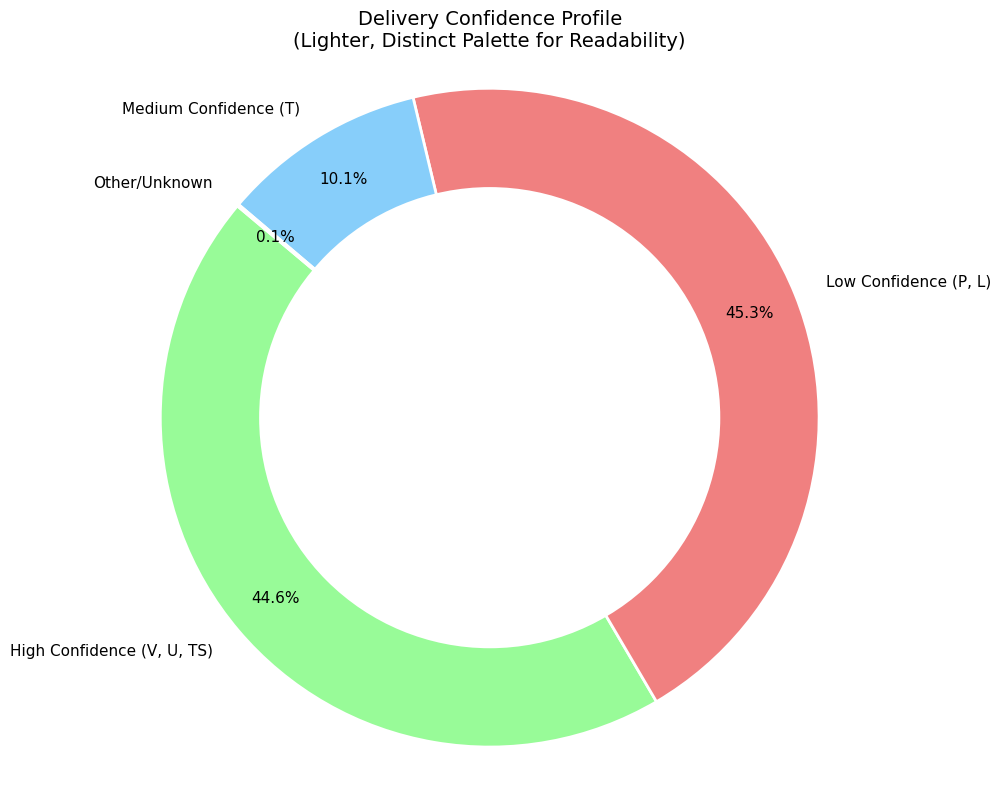

In [ ]:
# filter for planned files and clean energy technologies
clean_planned_df = all_generators_df[
    (all_generators_df['File_Type'] == 'Planned') &
    (all_generators_df['Technology'].isin(clean_energy_technologies))
].copy()
# refined mapping based on user legend
def map_confidence_refined(status):
    status = str(status).strip().upper()
    if status in ['V', 'U', 'TS']:
        return 'high confidence (v, u, ts)'
    elif status == 'T':
       return 'medium confidence (t)'
    elif status in ['P', 'L']:
        return 'low confidence (p, l)'
    else:
        return 'other/unknown'
clean_planned_df['Confidence_Level'] = clean_planned_df['Status'].apply(map_confidence_refined)

# aggregate capacity by refined confidence level
confidence_data = clean_planned_df.groupby('Confidence_Level')['Nameplate Capacity (MW)'].sum().reset_index()

# create the donut chart with a light, distinct palette
plt.figure(figsize=(10, 8))

# custom mapping for distinct light colors to ensure text readability
color_map = {
    'high confidence (v, u, ts)': '#98fb98', # palegreen
    'medium confidence (t)': '#87cefa',    # lightskyblue
    'low confidence (p, l)': '#f08080',    # lightcoral
    'other/unknown': '#f5f5f5'             # whitesmoke
}

# ensure labels match colors
labels = confidence_data['Confidence_Level'].tolist()
plot_colors = [color_map.get(label, '#d3d3d3') for label in labels]

plt.pie(
    confidence_data['Nameplate Capacity (MW)']ЕМ,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=plot_colors,
    pctdistance=0.85,
    textprops={'color': 'black', 'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('delivery confidence profile\n(lighter, distinct palette for readability)', fontsize=14, color='black')
plt.axis('equal')
plt.tight_layout()

total_planned_gw = confidence_data['Nameplate Capacity (MW)'].sum() / 1000
print(f"total planned capacity analyzed: {total_planned_gw:.1f} gw")
display(confidence_data)
plt.show()

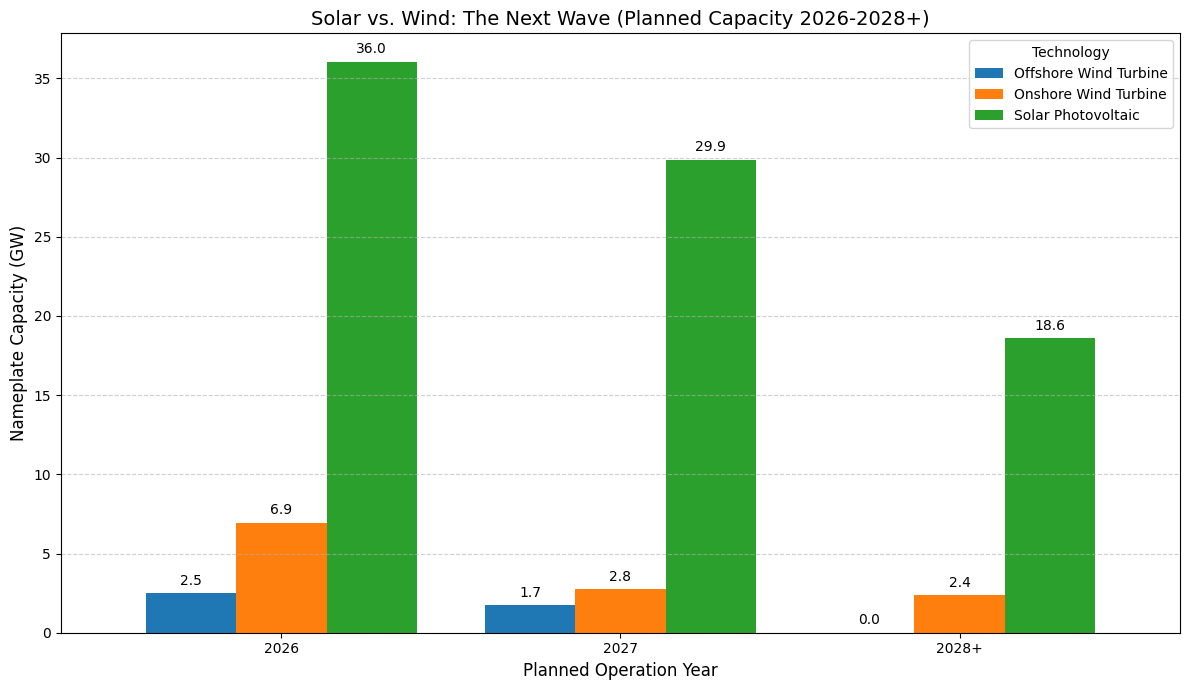

In [ ]:
# filter for planned clean energy projects for specific technologies
target_techs = ['Solar Photovoltaic', 'Onshore Wind Turbine', 'Offshore Wind Turbine']

tech_planned_df = all_generators_df[
    (all_generators_df['File_Type'] == 'Planned') &
    (all_generators_df['Technology'].isin(target_techs))
].copy()

# ensure 'planned operation year' is numeric
tech_planned_df['Planned Operation Year'] = pd.to_numeric(tech_planned_df['Planned Operation Year'], errors='coerce')

# categorize years into 2026, 2027, and 2028+
def categorize_planned_year(year):
    if pd.isna(year): return 'unknown'
    if year == 2026: return '2026'
    if year == 2027: return '2027'
    if year >= 2028: return '2028+'
    return 'pre-2026'

tech_planned_df['Year_Group'] = tech_planned_df['Planned Operation Year'].apply(categorize_planned_year)

# filter for specific year groups
year_order = ['2026', '2027', '2028+']
tech_planned_filtered = tech_planned_df[tech_planned_df['Year_Group'].isin(year_order)]

# aggregate capacity by year and technology
tech_comparison = tech_planned_filtered.groupby(['Year_Group', 'Technology'])['Nameplate Capacity (MW)'].sum().unstack(fill_value=0)

# reindex to ensure correct order of years
tech_comparison = tech_comparison.reindex(year_order)

# plot grouped bar chart
ax = (tech_comparison / 1000).plot(kind='bar', figsize=(12, 7), width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('solar vs. wind: the next wave (planned capacity 2026-2028+)', fontsize=14)
plt.xlabel('planned operation year', fontsize=12)
plt.ylabel('nameplate capacity (gw)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='technology')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()